# Perceptron

Neste relatório, será implementado um Perceptron de camada única utilizando apenas NumPy. O algoritmo será inicialmente aplicado a dados linearmente separáveis e, posteriormente, a dados com sobreposição entre as classes, permitindo analisar seu processo de convergência e suas limitações.

# Exercise 1

## A — Generate the data

Para o primeiro exercício, foram geradas duas classes bidimensionais, cada uma contendo 1.000 amostras. Os pontos foram obtidos de distribuições normais multivariadas com médias distintas e a mesma matriz de covariância.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Único gerador de números aleatórios utilizado em todo o relatório
rng = np.random.default_rng(42)

In [2]:
# Quantidade de amostras por classe
n_samples = 1000

# Parâmetros da Classe 0
mean_class_0 = np.array([1.5, 1.5])

# Parâmetros da Classe 1
mean_class_1 = np.array([5.0, 5.0])

# Matriz de covariância utilizada nas duas classes
covariance = np.array([
    [0.5, 0.0],
    [0.0, 0.5]
])

# Geração das amostras de cada classe
X_class_0 = rng.multivariate_normal(
    mean=mean_class_0,
    cov=covariance,
    size=n_samples
)

X_class_1 = rng.multivariate_normal(
    mean=mean_class_1,
    cov=covariance,
    size=n_samples
)

# União das amostras em uma única matriz de atributos
X = np.vstack((X_class_0, X_class_1))

# Criação dos rótulos: 0 para a primeira classe e 1 para a segunda
y = np.concatenate((
    np.zeros(n_samples, dtype=int),
    np.ones(n_samples, dtype=int)
))

print(f"Formato de X: {X.shape}")
print(f"Formato de y: {y.shape}")
print(f"Quantidade de amostras da Classe 0: {np.sum(y == 0)}")
print(f"Quantidade de amostras da Classe 1: {np.sum(y == 1)}")

Formato de X: (2000, 2)
Formato de y: (2000,)
Quantidade de amostras da Classe 0: 1000
Quantidade de amostras da Classe 1: 1000


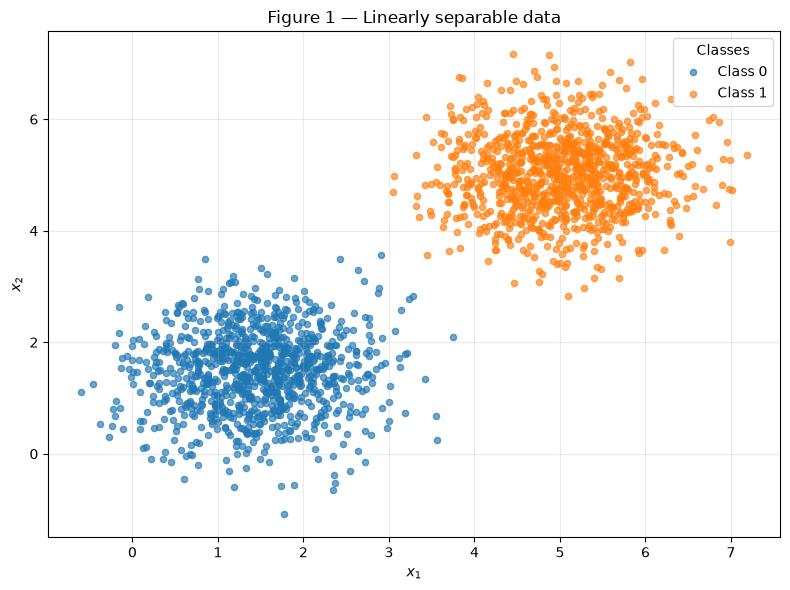

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    X_class_0[:, 0],
    X_class_0[:, 1],
    label="Class 0",
    color="tab:blue",
    alpha=0.65,
    s=20
)

ax.scatter(
    X_class_1[:, 0],
    X_class_1[:, 1],
    label="Class 1",
    color="tab:orange",
    alpha=0.65,
    s=20
)

ax.set_title("Figure 1 — Linearly separable data")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.legend(title="Classes")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

A Figura 1 apresenta as 2.000 amostras geradas, sendo 1.000 pertencentes a cada classe. A Classe 0 está concentrada ao redor da média $[1.5, 1.5]$, enquanto a Classe 1 está concentrada ao redor da média $[5, 5]$.

Visualmente, as duas classes formam nuvens bem definidas e claramente separadas. Embora existam pontos mais afastados dos centros das distribuições, não é observada uma sobreposição relevante entre as classes. Também há uma região vazia entre as duas nuvens, na qual uma fronteira linear pode ser posicionada.

Essa separação ocorre porque a distância entre as médias é grande em relação à dispersão determinada pela matriz de covariância. Portanto, os dados apresentados constituem um caso linearmente separável, adequado para o treinamento e a análise da convergência do Perceptron.

## B — Implement the perceptron

O Perceptron calcula inicialmente uma combinação linear entre os atributos de uma amostra e seus respectivos pesos:

$$
z = \mathbf{w} \cdot \mathbf{x} + b
$$

A classe prevista é determinada pela função degrau:

$$
\hat{y} =
\begin{cases}
1, & \text{se } z \geq 0 \\
0, & \text{se } z < 0
\end{cases}
$$

Quando uma amostra é classificada incorretamente, os pesos e o viés são atualizados utilizando o erro $y-\hat{y}$:

$$
\mathbf{w} \leftarrow \mathbf{w} + \eta(y-\hat{y})\mathbf{x}
$$

$$
b \leftarrow b + \eta(y-\hat{y})
$$

Como os rótulos utilizados são $0$ e $1$, o erro pode assumir os valores $-1$, $0$ ou $1$. Uma previsão correta produz erro zero e, consequentemente, não altera os parâmetros.

In [4]:
def step(z):
    """
    Aplica a função degrau.

    Retorna 1 quando z é maior ou igual a zero
    e 0 quando z é menor que zero.
    """
    return (np.asarray(z) >= 0).astype(int)


def predict(X, w, b):
    """
    Calcula as previsões do Perceptron.

    Parameters
    ----------
    X : np.ndarray
        Matriz contendo as amostras.
    w : np.ndarray
        Vetor de pesos.
    b : float
        Termo de viés.

    Returns
    -------
    np.ndarray
        Previsões contendo apenas 0 e 1.
    """
    linear_output = X @ w + b
    return step(linear_output)


def train_perceptron(
    X,
    y,
    rng,
    learning_rate=0.01,
    max_epochs=100,
    initial_w=None
):
    """
    Treina o Perceptron com a regra de atualização
    adequada para rótulos 0 e 1.
    """

    # Sorteia os pesos quando nenhuma inicialização é fornecida
    if initial_w is None:
        w = rng.normal(0, 0.01, size=X.shape[1])
    else:
        # Copia os pesos fornecidos para não modificar o vetor original
        w = np.asarray(initial_w, dtype=float).copy()

    # Guarda a inicialização utilizada
    initial_w_used = w.copy()

    # Inicialização do viés
    b = 0.0

    # Históricos do treinamento
    accuracy_history = []
    updates_history = []

    for epoch in range(max_epochs):
        updates = 0

        for x_i, y_i in zip(X, y):
            y_hat = step(np.dot(w, x_i) + b).item()
            error = y_i - y_hat

            if error != 0:
                w = w + learning_rate * error * x_i
                b = b + learning_rate * error
                updates += 1

        predictions = predict(X, w, b)
        accuracy = np.mean(predictions == y)

        accuracy_history.append(accuracy)
        updates_history.append(updates)

        if updates == 0:
            break

    return {
        "initial_w": initial_w_used,
        "w": w,
        "b": b,
        "epochs": len(accuracy_history),
        "accuracy": accuracy_history[-1],
        "accuracy_history": np.array(accuracy_history),
        "updates_history": np.array(updates_history)
    }

In [5]:
test_z = np.array([-2.0, -0.1, 0.0, 0.1, 2.0])

test_X = np.array([
    [1.0, 2.0],
    [3.0, 1.0]
])

test_w = np.array([1.0, -1.0])
test_b = 0.0

print("Saída da função step:", step(test_z))
print("Previsões de teste:", predict(test_X, test_w, test_b))

Saída da função step: [0 0 1 1 1]
Previsões de teste: [0 1]


## C — Train and measure

O Perceptron foi treinado com taxa de aprendizagem $\eta=0.01$ e limite máximo de 100 épocas. O treinamento é interrompido antecipadamente quando uma passagem completa pelo conjunto de dados não produz nenhuma atualização dos parâmetros.

In [6]:
result_001 = train_perceptron(
    X=X,
    y=y,
    rng=rng,
    learning_rate=0.01,
    max_epochs=100
)

w_001 = result_001["w"]
b_001 = result_001["b"]
epochs_001 = result_001["epochs"]
accuracy_001 = result_001["accuracy"]
accuracy_history_001 = result_001["accuracy_history"]
updates_history_001 = result_001["updates_history"]

print(
    "Pesos finais:",
    np.array2string(w_001, precision=8)
)
print(f"Viés final: {b_001:.8f}")
print(f"Quantidade de épocas: {epochs_001}")
print(f"Acurácia final: {accuracy_001:.4%}")
print(f"Atualizações por época: {updates_history_001}")

Pesos finais: [0.05049707 0.02887168]
Viés final: -0.25000000
Quantidade de épocas: 26
Acurácia final: 100.0000%
Atualizações por época: [3 3 4 4 3 4 3 4 2 4 2 4 2 3 3 3 2 3 3 2 3 3 2 3 1 0]


O treinamento com taxa de aprendizagem $\eta=0.01$ convergiu após **26 épocas**. Os parâmetros finais encontrados foram:

$$
\mathbf{w} = [0.05049707,\ 0.02887168]
$$

$$
b = -0.25000000
$$

A acurácia final foi de **100%**, indicando que todas as 2.000 amostras foram classificadas corretamente. Na última época, nenhuma atualização foi realizada, atendendo à condição de parada definida para o treinamento.

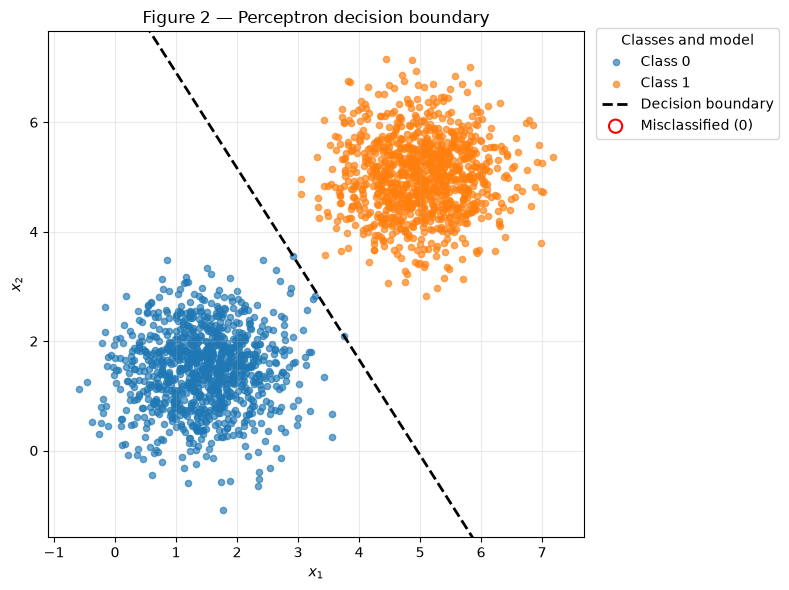

Quantidade de amostras classificadas incorretamente: 0


In [7]:
# Predições obtidas com os parâmetros finais
predictions_001 = predict(X, w_001, b_001)

# Identificação das amostras classificadas incorretamente
misclassified_001 = predictions_001 != y
n_misclassified_001 = np.sum(misclassified_001)

# Valores utilizados para desenhar a fronteira de decisão
x_boundary = np.linspace(
    X[:, 0].min() - 0.5,
    X[:, 0].max() + 0.5,
    300
)

# Da equação w1*x1 + w2*x2 + b = 0:
# x2 = -(w1*x1 + b) / w2
y_boundary = -(
    w_001[0] * x_boundary + b_001
) / w_001[1]

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    X_class_0[:, 0],
    X_class_0[:, 1],
    label="Class 0",
    color="tab:blue",
    alpha=0.65,
    s=20
)

ax.scatter(
    X_class_1[:, 0],
    X_class_1[:, 1],
    label="Class 1",
    color="tab:orange",
    alpha=0.65,
    s=20
)

ax.plot(
    x_boundary,
    y_boundary,
    color="black",
    linewidth=2,
    linestyle="--",
    label="Decision boundary"
)

# Destaca os erros, caso existam
if n_misclassified_001 > 0:
    ax.scatter(
        X[misclassified_001, 0],
        X[misclassified_001, 1],
        facecolors="none",
        edgecolors="red",
        linewidths=1.5,
        s=90,
        label=f"Misclassified ({n_misclassified_001})"
    )
else:
    # Entrada vazia para registrar na legenda que não houve erros
    ax.scatter(
        [],
        [],
        facecolors="none",
        edgecolors="red",
        linewidths=1.5,
        s=90,
        label="Misclassified (0)"
    )

ax.set_xlim(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5)
ax.set_ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)

ax.set_title("Figure 2 — Perceptron decision boundary")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.legend(title="Classes and model",bbox_to_anchor = (1.01,1.02))
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"Quantidade de amostras classificadas incorretamente: {n_misclassified_001}")

A Figura 2 mostra que a fronteira de decisão aprendida pelo Perceptron foi posicionada na região vazia existente entre as duas nuvens. Os pontos da Classe 0 permanecem de um lado da fronteira, enquanto os pontos da Classe 1 permanecem do lado oposto.

Nenhuma das 2.000 amostras foi classificada incorretamente, o que é consistente com a acurácia final de 100%. Os dois pesos positivos fazem com que valores maiores de $x_1$ e $x_2$ favoreçam a previsão da Classe 1, enquanto o viés negativo desloca a fronteira de decisão para longe da origem.

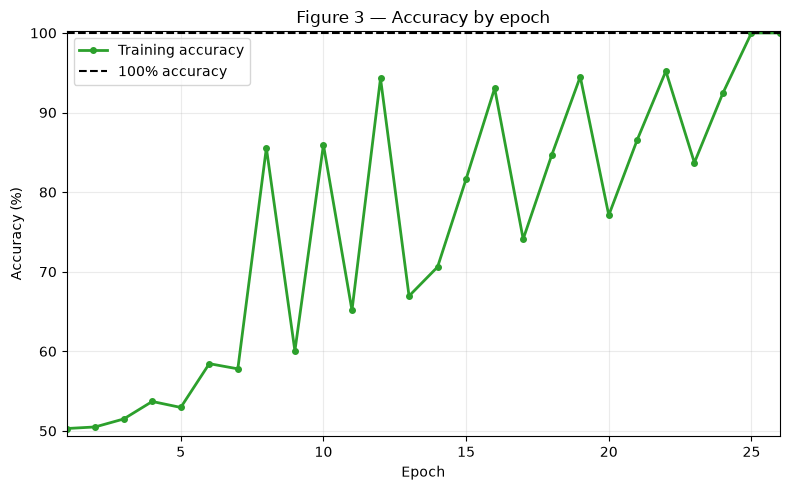

In [ ]:
epochs_axis_001 = np.arange(1, epochs_001 + 1)
accuracy_percent_001 = accuracy_history_001 * 100

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    epochs_axis_001,
    accuracy_percent_001,
    color="tab:green",
    marker="o",
    markersize=4,
    linewidth=2,
    label="Training accuracy"
)

ax.axhline(
    100,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="100% accuracy"
)

ax.set_title("Figure 3 — Accuracy by epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy (%)")
ax.set_xlim(1, epochs_001)
ax.set_ylim(
    max(0, accuracy_percent_001.min() - 1),
    100.2
)
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

A Figura 3 mostra que a acurácia apresenta uma tendência geral de crescimento ao longo do treinamento, partindo de aproximadamente 50% e alcançando 100% nas épocas finais. Entretanto, esse crescimento não é monotônico: existem quedas temporárias entre algumas épocas.

Essas oscilações ocorrem porque a atualização causada por uma amostra classificada incorretamente desloca a fronteira de decisão. Esse deslocamento pode corrigir a amostra atual, mas também pode fazer com que outras amostras anteriormente corretas passem a ser classificadas incorretamente.

A acurácia chegou a 100% ao final da época 25, mas essa época ainda apresentou uma atualização dos parâmetros. O treinamento foi encerrado somente na época 26, quando todas as amostras foram percorridas sem nenhuma atualização. Isso confirma o cumprimento da condição de parada estabelecida.

## D — Analysis

### 1. Convergence on separable data

Os dados linearmente separáveis convergem porque existe ao menos uma fronteira linear capaz de classificar corretamente todas as amostras. Sempre que o Perceptron comete um erro, seus parâmetros são atualizados de acordo com:

$$
\mathbf{w} \leftarrow \mathbf{w} + \eta(y-\hat{y})\mathbf{x}
$$

$$
b \leftarrow b + \eta(y-\hat{y})
$$

Quando a previsão está correta, $y-\hat{y}=0$ e nenhuma atualização é realizada. Quando ocorre um erro, o sinal de $y-\hat{y}$ modifica os pesos e o viés em uma direção que favorece a classificação correta da amostra observada.

Neste treinamento, a quantidade de atualizações por época não diminuiu de forma estritamente monotônica. Nas primeiras épocas, ela oscilou principalmente entre duas e quatro atualizações, porque a correção de uma amostra podia deslocar a fronteira e afetar outras classificações. Entretanto, à medida que a fronteira se aproximou de uma posição capaz de separar as classes, os erros tornaram-se menos frequentes.

Na época 25 ocorreu apenas uma atualização, e na época 26 nenhuma atualização foi necessária. Portanto, a convergência foi confirmada quando uma passagem completa pelas 2.000 amostras terminou com zero atualizações e acurácia de 100%.

### 2. Effect of the learning rate

Para analisar o efeito da taxa de aprendizagem, o Perceptron foi treinado novamente com $\eta=1.0$. Foram mantidos os mesmos dados, a mesma ordem das amostras, o mesmo limite de épocas, o mesmo viés inicial e exatamente os mesmos pesos iniciais utilizados no treinamento com $\eta=0.01$. Dessa forma, a única variável alterada foi a taxa de aprendizagem.

In [10]:
result_100 = train_perceptron(
    X=X,
    y=y,
    rng=rng,
    learning_rate=1.0,
    max_epochs=100,
    initial_w=result_001["initial_w"]
)

w_100 = result_100["w"]
b_100 = result_100["b"]
epochs_100 = result_100["epochs"]
accuracy_100 = result_100["accuracy"]

# Direções normalizadas dos vetores de pesos
direction_001 = w_001 / np.linalg.norm(w_001)
direction_100 = w_100 / np.linalg.norm(w_100)

# Comparação angular entre as direções
cosine_similarity = np.dot(direction_001, direction_100)

angle_degrees = np.degrees(
    np.arccos(
        np.clip(cosine_similarity, -1.0, 1.0)
    )
)

print(
    "Pesos iniciais utilizados:",
    np.array2string(result_001["initial_w"], precision=8)
)
print(
    "Pesos finais com eta = 1.0:",
    np.array2string(w_100, precision=8)
)
print(f"Viés final com eta = 1.0: {b_100:.8f}")
print(f"Quantidade de épocas com eta = 1.0: {epochs_100}")
print(f"Acurácia final com eta = 1.0: {accuracy_100:.4%}")

print(
    "Direção normalizada com eta = 0.01:",
    np.array2string(direction_001, precision=8)
)
print(
    "Direção normalizada com eta = 1.0:",
    np.array2string(direction_100, precision=8)
)
print(f"Similaridade de cosseno: {cosine_similarity:.10f}")
print(f"Ângulo entre as direções: {angle_degrees:.6f} graus")

Pesos iniciais utilizados: [0.00253205 0.00895218]
Pesos finais com eta = 1.0: [5.87061596 3.3592393 ]
Viés final com eta = 1.0: -31.00000000
Quantidade de épocas com eta = 1.0: 37
Acurácia final com eta = 1.0: 100.0000%
Direção normalizada com eta = 0.01: [0.86812305 0.49634905]
Direção normalizada com eta = 1.0: [0.86794992 0.49665172]
Similaridade de cosseno: 0.9999999392
Ângulo entre as direções: 0.019978 graus


Com os mesmos pesos iniciais $\mathbf{w}_0=[0.00253205,\ 0.00895218]$, os dois treinamentos alcançaram acurácia final de 100%. Entretanto, a quantidade de épocas e os parâmetros finais foram diferentes.

| Taxa de aprendizagem | Épocas | Pesos finais | Viés final | Acurácia |
|---:|---:|---|---:|---:|
| $\eta=0.01$ | 26 | $[0.05049707,\ 0.02887168]$ | $-0.25$ | 100% |
| $\eta=1.0$ | 37 | $[5.87061596,\ 3.35923930]$ | $-31.00$ | 100% |

As direções normalizadas encontradas foram:

$$
\frac{\mathbf{w}_{0.01}}{\lVert\mathbf{w}_{0.01}\rVert}
=
[0.86812305,\ 0.49634905]
$$

$$
\frac{\mathbf{w}_{1.0}}{\lVert\mathbf{w}_{1.0}\rVert}
=
[0.86794992,\ 0.49665172]
$$

A similaridade de cosseno entre essas direções foi $0.9999999392$, equivalente a um ângulo de aproximadamente $0.019978^\circ$. Portanto, os vetores finais são quase paralelos, mas não exatamente iguais.

A taxa de aprendizagem controla o tamanho de cada correção realizada após uma classificação incorreta. Com $\eta=1.0$, cada atualização é 100 vezes maior do que com $\eta=0.01$. Como os pesos iniciais são não nulos e possuem magnitude próxima de $0.01$, a contribuição relativa dessa inicialização é diferente nos dois treinamentos.

De forma geral, após uma sequência de atualizações, os pesos podem ser escritos como:

$$
\mathbf{w}_t
=
\mathbf{w}_0
+
\eta\sum_i (y_i-\hat{y}_i)\mathbf{x}_i
$$

Como $\mathbf{w}_0\neq\mathbf{0}$ e não é multiplicado por $\eta$, alterar a taxa de aprendizagem não produz apenas uma multiplicação uniforme de todo o vetor de pesos. A trajetória da fronteira muda, podendo alterar a sequência de erros e a quantidade de épocas necessárias.

Embora as direções encontradas tenham sido muito próximas neste conjunto de dados, os vieses finais e as magnitudes dos pesos foram diferentes. Consequentemente, as fronteiras de decisão não são exatamente iguais, apesar de ambas separarem corretamente as duas classes.

| Comparação | Resultado |
|---|---|
| Ambas convergiram? | Sim |
| Ambas alcançaram 100%? | Sim |
| Mesmo número de épocas? | Não: 26 contra 37 |
| Mesma direção de `w`? | Quase, mas não exatamente |
| Mesma fronteira? | Não |
| `η = 1.0` foi mais rápido? | Não neste experimento |

### 3. Zero initialization and learning-rate invariance

Considere agora que o treinamento seja iniciado com pesos e viés nulos:

$$
\mathbf{w}_0=\mathbf{0},
\qquad
b_0=0
$$

Após uma sequência de $t$ atualizações utilizando uma taxa de aprendizagem $\eta$, os parâmetros podem ser escritos como:

$$
\mathbf{w}_t^{(\eta)}
=
\eta
\sum_{k=1}^{t}
e_k\mathbf{x}_k
$$

$$
b_t^{(\eta)}
=
\eta
\sum_{k=1}^{t}
e_k
$$

em que $e_k=y_k-\hat{y}_k$ é o erro associado à atualização $k$.

Considere dois treinamentos com taxas positivas $\eta_1$ e $\eta_2$. Se ambos começam com parâmetros nulos e recebem as amostras na mesma ordem, então:

$$
\mathbf{w}_t^{(\eta_2)}
=
\frac{\eta_2}{\eta_1}
\mathbf{w}_t^{(\eta_1)}
$$

e

$$
b_t^{(\eta_2)}
=
\frac{\eta_2}{\eta_1}
b_t^{(\eta_1)}
$$

Como $\eta_2/\eta_1>0$, a combinação linear do segundo treinamento também é apenas uma versão positivamente escalada da primeira:

$$
\mathbf{w}_t^{(\eta_2)}\cdot\mathbf{x}
+
b_t^{(\eta_2)}
=
\frac{\eta_2}{\eta_1}
\left(
\mathbf{w}_t^{(\eta_1)}\cdot\mathbf{x}
+
b_t^{(\eta_1)}
\right)
$$

A multiplicação por uma constante positiva não altera o sinal da combinação linear. Portanto, os dois treinamentos produzem a mesma previsão para cada amostra, inclusive quando a combinação linear é zero:

$$
\operatorname{step}
\left(
\mathbf{w}_t^{(\eta_2)}\cdot\mathbf{x}
+
b_t^{(\eta_2)}
\right)
=
\operatorname{step}
\left(
\mathbf{w}_t^{(\eta_1)}\cdot\mathbf{x}
+
b_t^{(\eta_1)}
\right)
$$

Como as previsões são iguais, os erros também são iguais. Consequentemente, os dois treinamentos realizam atualizações nas mesmas amostras e nas mesmas épocas, preservando a relação de proporcionalidade durante todo o processo.

Além disso, multiplicar toda a equação da fronteira por uma constante positiva não altera o conjunto de pontos que satisfaz:

$$
\mathbf{w}\cdot\mathbf{x}+b=0
$$

Logo, partindo de $\mathbf{w}_0=\mathbf{0}$ e $b_0=0$, diferentes taxas de aprendizagem produziriam parâmetros com magnitudes diferentes, mas exatamente a mesma fronteira de decisão, as mesmas previsões e o mesmo número de épocas. Por esse motivo, o enunciado exige uma inicialização não nula para que o efeito de $\eta$ possa ser analisado.